In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_2/UGC-409_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_2/UGC-409_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [4]:
image_cut = image[65:185, 0:1890]
image_error_cut = image_error[65:185, 0:1890]

Text(0.5, 0, 'wavelength')

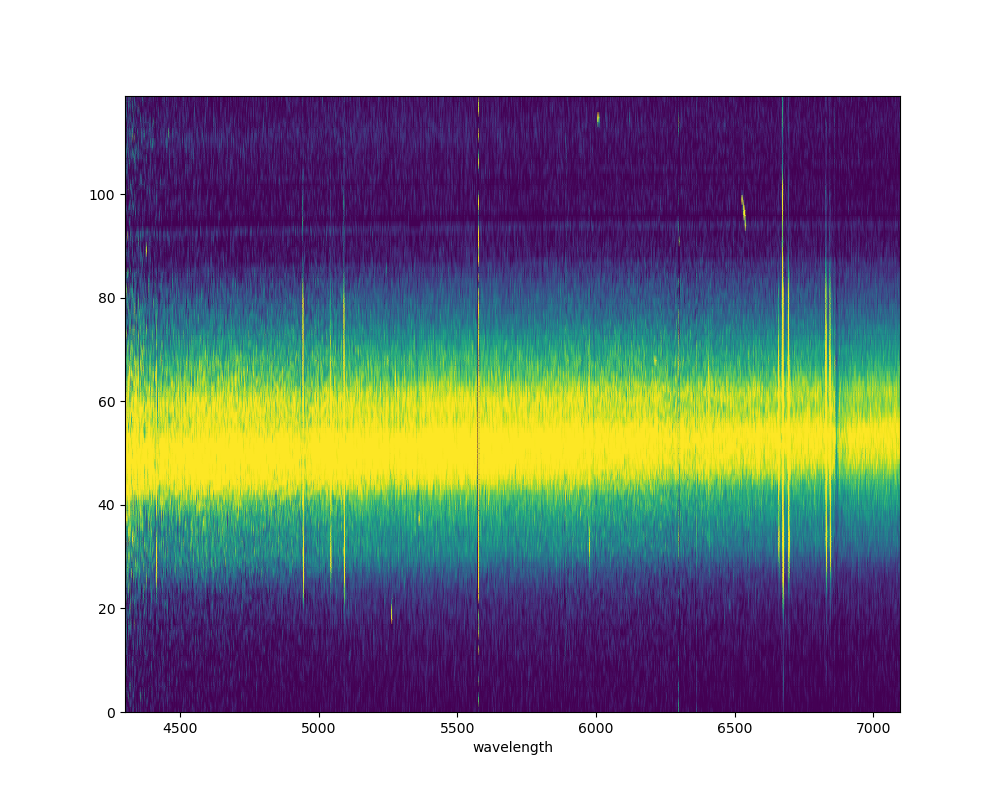

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.01736
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/PSF/Real_seeing_UGC409.txt")
sigmas = seeing / 2.35
print(sigmas)

[2.18004842 2.5199744  2.17810166 2.16914413 2.48282011 2.19531915]


## Sky lines

Filename: C:/Users/ISAFA\Desktop/Tesi magistrale/Sources/UGC409/UGC409_2/FORS2.2021-10-05T05_40_37.236/UGC-409_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

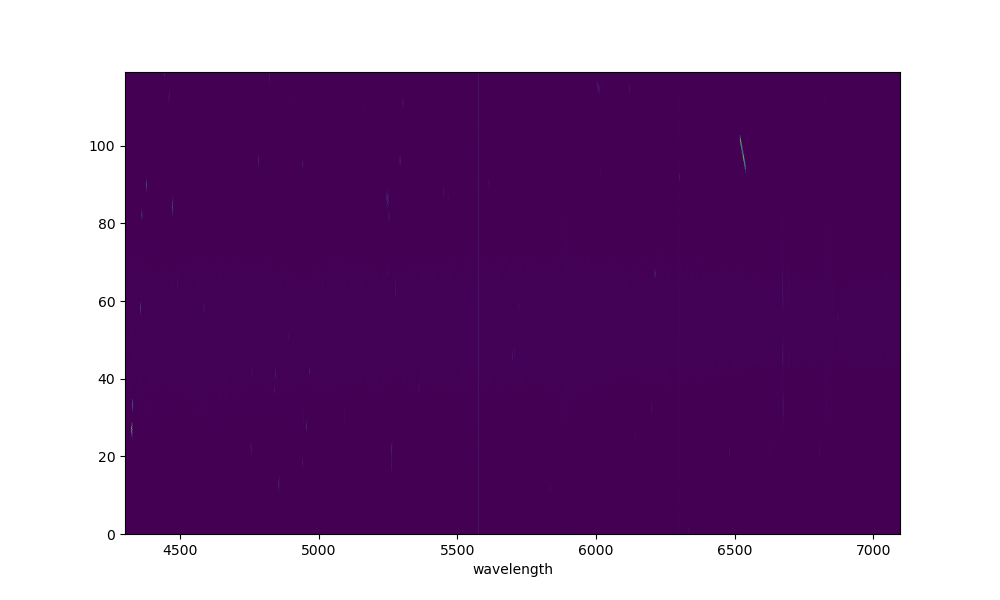

In [7]:
hdul2 = fits.open("C:/Users/ISAFA\Desktop/Tesi magistrale/Sources/UGC409/UGC409_2/FORS2.2021-10-05T05_40_37.236/UGC-409_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[65:185, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

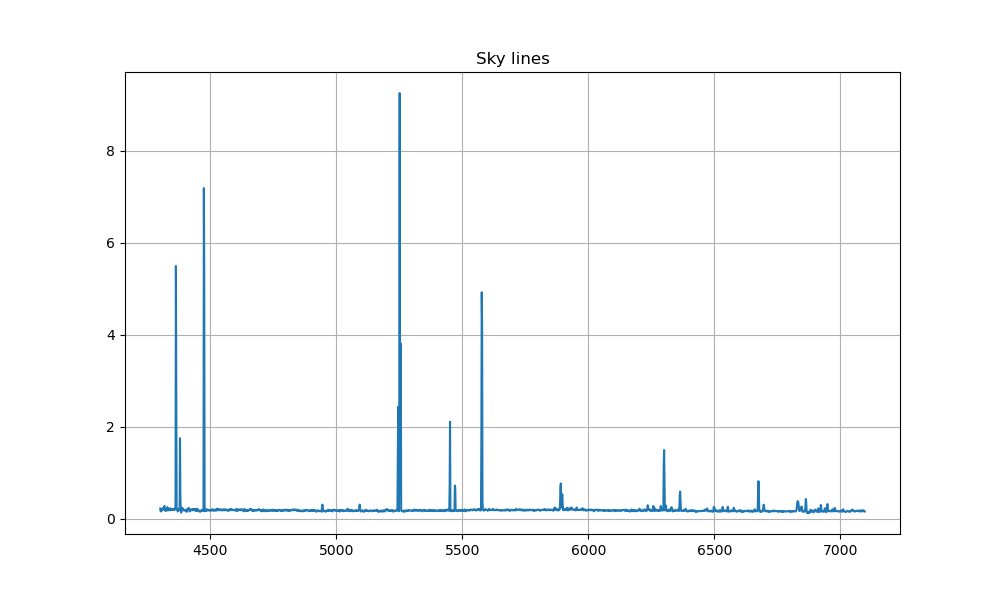

In [8]:
mask_sky = (y > 80)*(y < 90)
mask_wv = wv > 0
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

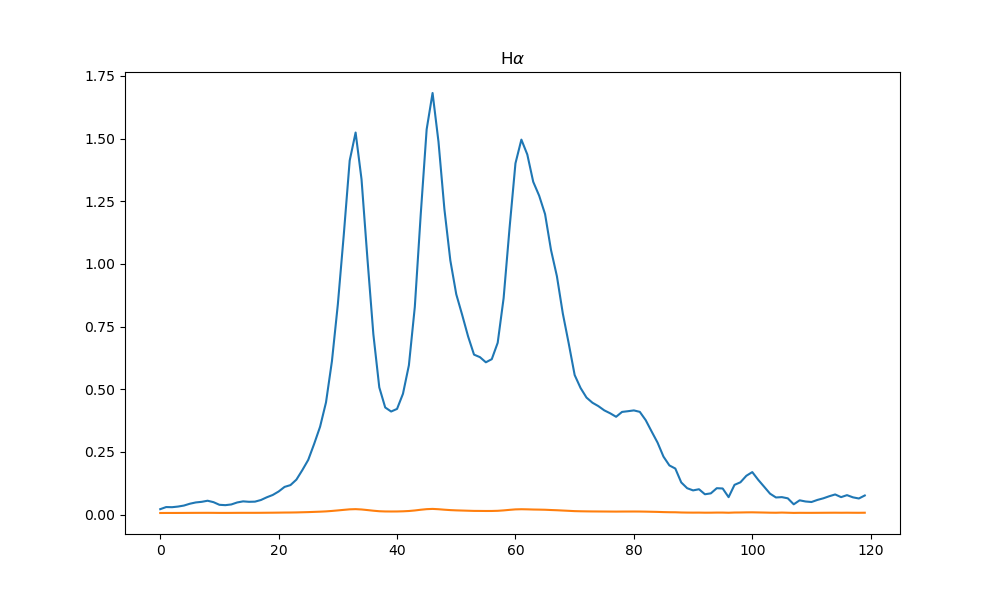

In [10]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_2/FORS2.2021-10-05T05_40_37.236/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [18]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.8)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 1.8)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
     (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (27, 37),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (57, 65),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (75, 85),    # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (95, 105),   # x_0: posizione da 0 a 100
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [19]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 37193.24723930288
differential_evolution step 2: f(x)= 24952.38302274821
differential_evolution step 3: f(x)= 24952.38302274821
differential_evolution step 4: f(x)= 11881.547381488577
differential_evolution step 5: f(x)= 3582.838620592092
differential_evolution step 6: f(x)= 2037.1783069296946
differential_evolution step 7: f(x)= 2037.1783069296946
differential_evolution step 8: f(x)= 2037.1783069296946
differential_evolution step 9: f(x)= 2037.1783069296946
differential_evolution step 10: f(x)= 2037.1783069296946
differential_evolution step 11: f(x)= 2037.1783069296946
differential_evolution step 12: f(x)= 2037.1783069296946
differential_evolution step 13: f(x)= 770.5615318975883
differential_evolution step 14: f(x)= 770.5615318975883
differential_evolution step 15: f(x)= 770.5615318975883
differential_evolution step 16: f(x)= 770.5615318975883
differential_evolution step 17: f(x)= 623.0746463480438
differential_evolution step 18: f(x)= 623.0746463

Sérsic 1: I_e=0.0775, r_e=9.7837, n=2.5924, x_0=32.6686
Sérsic 2: I_e=0.3264, r_e=3.1911, n=1.5908, x_0=46.0798
Sérsic 3: I_e=0.1868, r_e=15.2031, n=1.4051, x_0=62.1469
Sérsic 4: I_e=0.0128, r_e=37.8729, n=2.0690, x_0=80.0820
Sérsic 5: I_e=0.7997, r_e=0.0864, n=1.4566, x_0=99.9088


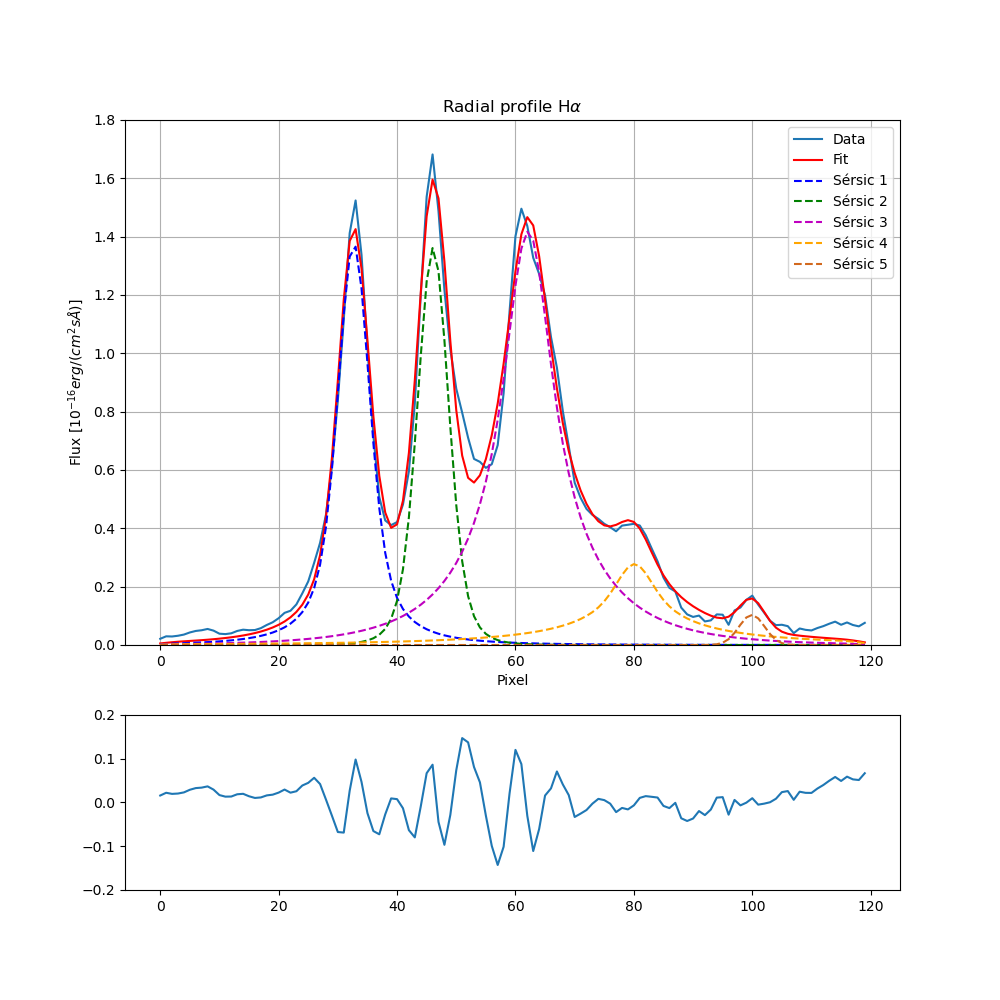

In [20]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [21]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)#, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0532, r_e=12.0441, n=2.9110, x_0=32.6439
Sérsic 2: I_e=0.3408, r_e=3.4043, n=1.4416, x_0=46.2214
Sérsic 3: I_e=0.1806, r_e=14.8149, n=1.4244, x_0=62.2546
Sérsic 4: I_e=0.0042, r_e=128.9295, n=2.7024, x_0=80.0472
Sérsic 5: I_e=0.7093, r_e=0.0753, n=1.2433, x_0=99.9852
[1.38005683e-01 1.93293740e+01 3.80676749e+00 2.92242541e-03
 2.84948705e-01 1.73755673e+00 7.26362936e-01 8.31220322e-02
 1.43941889e-01 1.12694425e+01 5.22089567e-01 1.24515026e-01
 1.40852523e-02 3.29384483e+02 2.21337615e+00 5.26140248e-01
 3.82388326e+05 6.50622795e+03 4.90897809e+05 3.63734967e+01]
0.4756106873272358


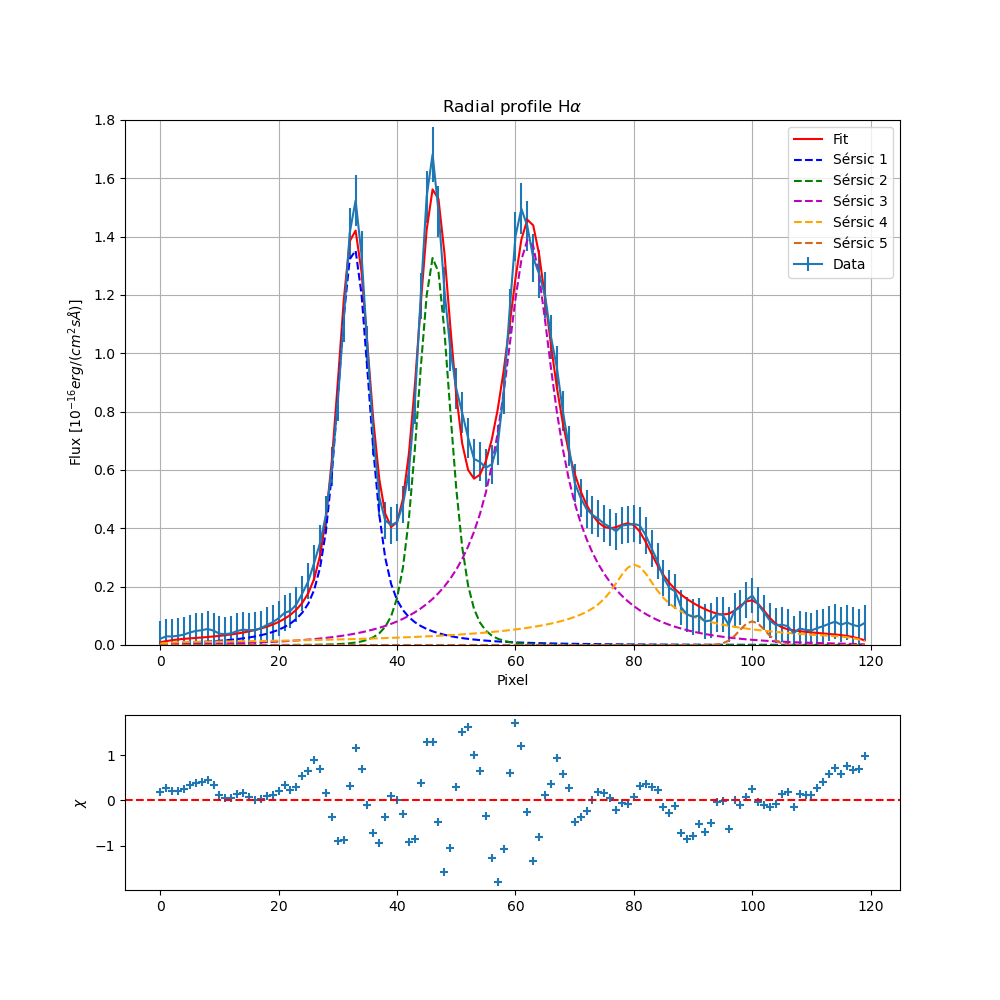

In [22]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [23]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: posizione da 0 a 100

    (0, 10),
    (5, 20),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),   # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 20),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

bounds_OIII = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (27, 37),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (5, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (57, 65),   # x_0: posizione da 0 a 100
    
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (75, 85),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 10),
    (0.1, 10),
    (95, 105),
]

## H$\beta$

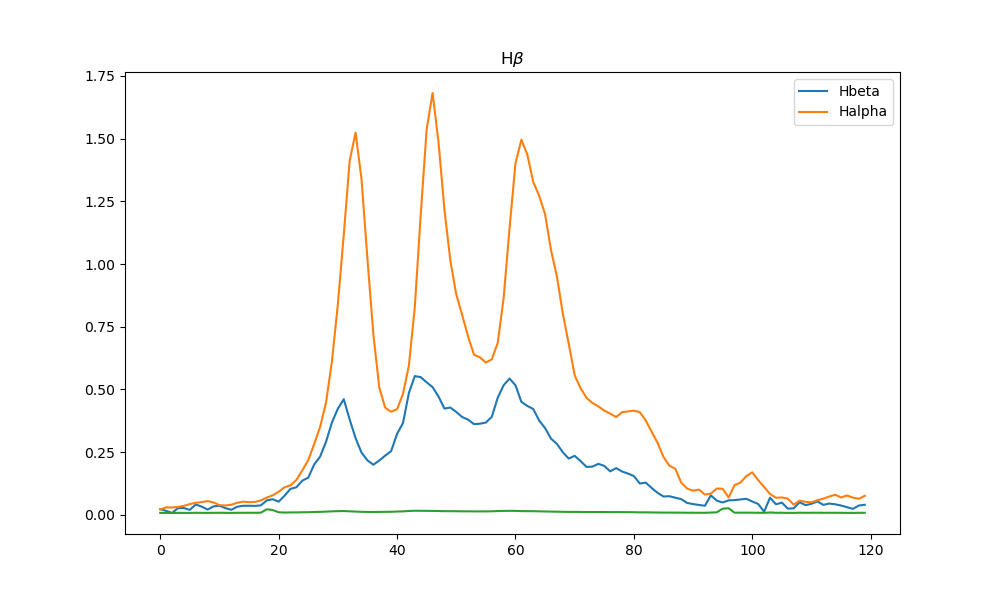

In [24]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 120, 1)
plt.plot(x_axes, radial_profile_HB, label ='Hbeta')
plt.plot(x_axes, radial_profile_HA, label = 'Halpha')
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')
plt.legend()

In [25]:
# Bounds:
bounds = bounds_OIII

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3789.983155323043
differential_evolution step 2: f(x)= 2132.0998226314487
differential_evolution step 3: f(x)= 2132.0998226314487
differential_evolution step 4: f(x)= 1474.275064052328
differential_evolution step 5: f(x)= 1366.9711406417264
differential_evolution step 6: f(x)= 1366.9711406417264
differential_evolution step 7: f(x)= 632.5805185639396
differential_evolution step 8: f(x)= 632.5805185639396
differential_evolution step 9: f(x)= 632.5805185639396
differential_evolution step 10: f(x)= 632.5805185639396
differential_evolution step 11: f(x)= 339.9088227572671
differential_evolution step 12: f(x)= 339.9088227572671
differential_evolution step 13: f(x)= 250.58415211569292
differential_evolution step 14: f(x)= 219.31358864220292
differential_evolution step 15: f(x)= 63.66170852194276
differential_evolution step 16: f(x)= 63.66170852194276
differential_evolution step 17: f(x)= 63.66170852194276
differential_evolution step 18: f(x)= 63.6617085219

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.0046, r_e=41.7605, n=3.5696, x_0=30.1740
Sérsic 2: I_e=0.0518, r_e=10.8527, n=1.7595, x_0=44.5045
Sérsic 3: I_e=0.1335, r_e=9.4186, n=0.8470, x_0=59.3674
Sérsic 4: I_e=0.0289, r_e=19.6938, n=1.0355, x_0=76.7705
Sérsic 5: I_e=0.8256, r_e=0.0286, n=5.9606, x_0=99.4303
Chi quadro minimo: 0.05257212031779286
False


Sérsic 1: I_e=0.0046, r_e=41.7605, n=3.5696, x_0=30.1740
Sérsic 2: I_e=0.0518, r_e=10.8527, n=1.7595, x_0=44.5045
Sérsic 3: I_e=0.1335, r_e=9.4186, n=0.8470, x_0=59.3674
Sérsic 4: I_e=0.0289, r_e=19.6938, n=1.0355, x_0=76.7705
Sérsic 5: I_e=0.8256, r_e=0.0286, n=5.9606, x_0=99.4303


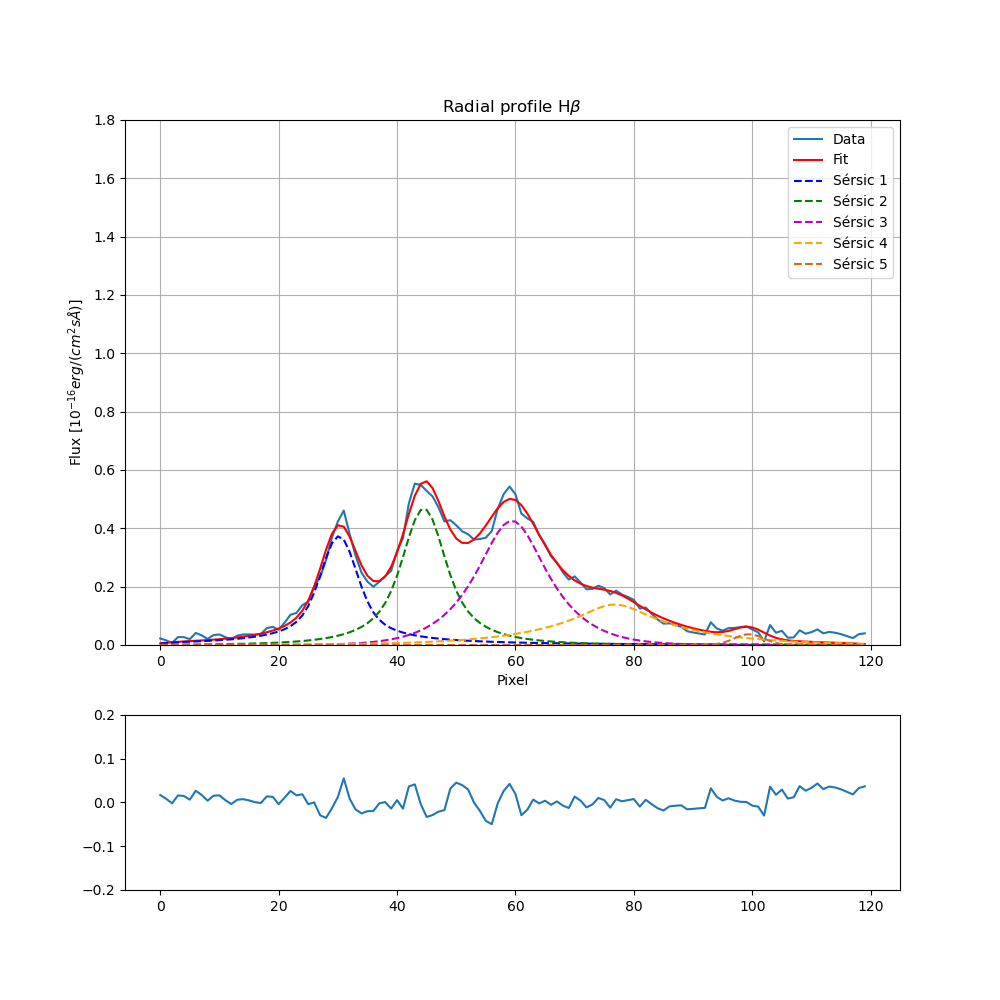

In [26]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [27]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0046, r_e=41.7605, n=3.5695, x_0=30.1740
Sérsic 2: I_e=0.0518, r_e=10.8528, n=1.7594, x_0=44.5044
Sérsic 3: I_e=0.1335, r_e=9.4186, n=0.8470, x_0=59.3674
Sérsic 4: I_e=0.0289, r_e=19.6938, n=1.0355, x_0=76.7705
Sérsic 5: I_e=0.8256, r_e=0.0286, n=5.9606, x_0=99.4304
[2.67828129e-02 1.58748641e+02 6.77994970e+00 7.02684360e-04
 1.11696980e-01 1.88407396e+01 1.53440270e+00 1.82387094e-01
 9.25806531e-02 6.92100949e+00 4.53460021e-01 2.98000558e-01
 2.83754603e-02 1.15693345e+01 4.28202441e-01 2.10552049e+00
 9.68590877e+04 1.95307522e+03 3.27608327e+05 5.80487616e+01]
0.13494569805059212


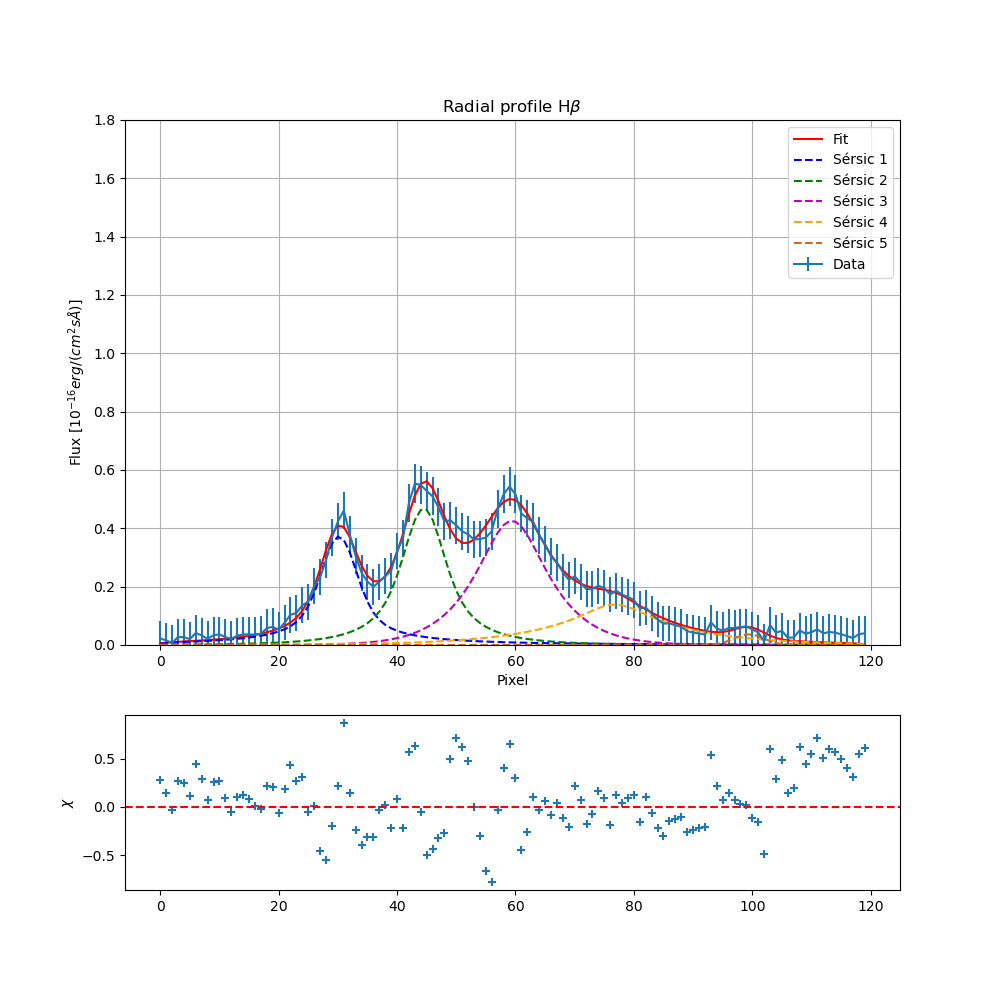

In [28]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

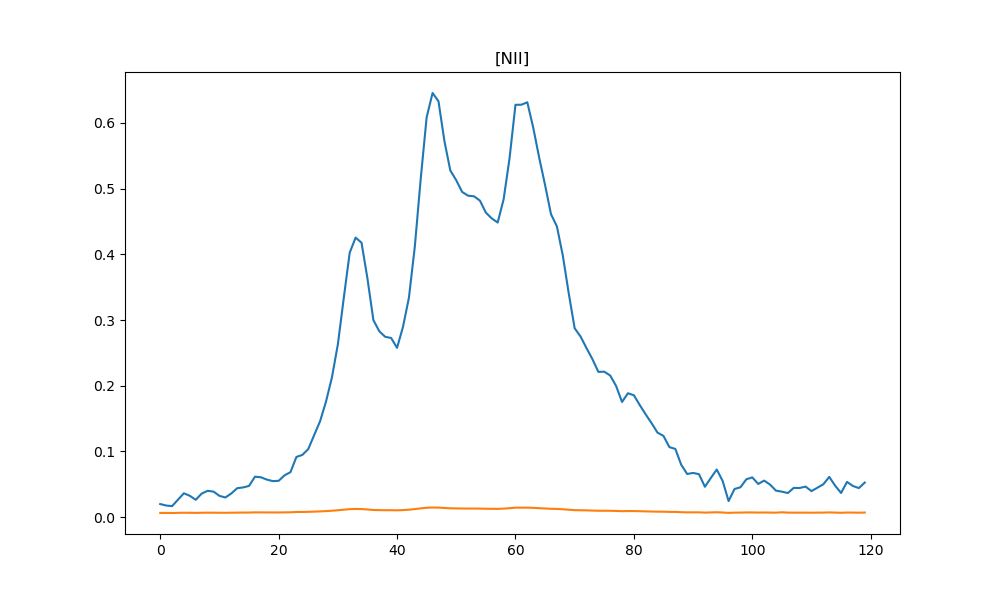

In [29]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [30]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 45551.49799112171
differential_evolution step 2: f(x)= 21936.817790063207
differential_evolution step 3: f(x)= 21936.817790063207
differential_evolution step 4: f(x)= 9439.992811544153
differential_evolution step 5: f(x)= 4301.238551355679
differential_evolution step 6: f(x)= 4301.238551355679
differential_evolution step 7: f(x)= 3531.4133346286762
differential_evolution step 8: f(x)= 3531.4133346286762
differential_evolution step 9: f(x)= 1660.4742890793773
differential_evolution step 10: f(x)= 759.0292041834139
differential_evolution step 11: f(x)= 759.0292041834139
differential_evolution step 12: f(x)= 759.0292041834139
differential_evolution step 13: f(x)= 759.0292041834139
differential_evolution step 14: f(x)= 435.45798837768655
differential_evolution step 15: f(x)= 435.45798837768655
differential_evolution step 16: f(x)= 435.45798837768655
differential_evolution step 17: f(x)= 435.45798837768655
differential_evolution step 18: f(x)= 435.457988

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=0.1433, r_e=2.2446, n=0.9180, x_0=32.7220
Sérsic 2: I_e=0.0354, r_e=18.4131, n=1.8285, x_0=46.6002
Sérsic 3: I_e=0.0433, r_e=41.7785, n=1.6457, x_0=61.8315
Sérsic 4: I_e=0.1335, r_e=0.0786, n=4.4999, x_0=80.1505
Sérsic 5: I_e=0.0496, r_e=0.0000, n=0.8523, x_0=100.5415
Chi quadro minimo: 0.037829938195145504
False


Sérsic 1: I_e=0.1433, r_e=2.2446, n=0.9180, x_0=32.7220
Sérsic 2: I_e=0.0354, r_e=18.4131, n=1.8285, x_0=46.6002
Sérsic 3: I_e=0.0433, r_e=41.7785, n=1.6457, x_0=61.8315
Sérsic 4: I_e=0.1335, r_e=0.0786, n=4.4999, x_0=80.1505
Sérsic 5: I_e=0.0496, r_e=0.0000, n=0.8523, x_0=100.5415


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


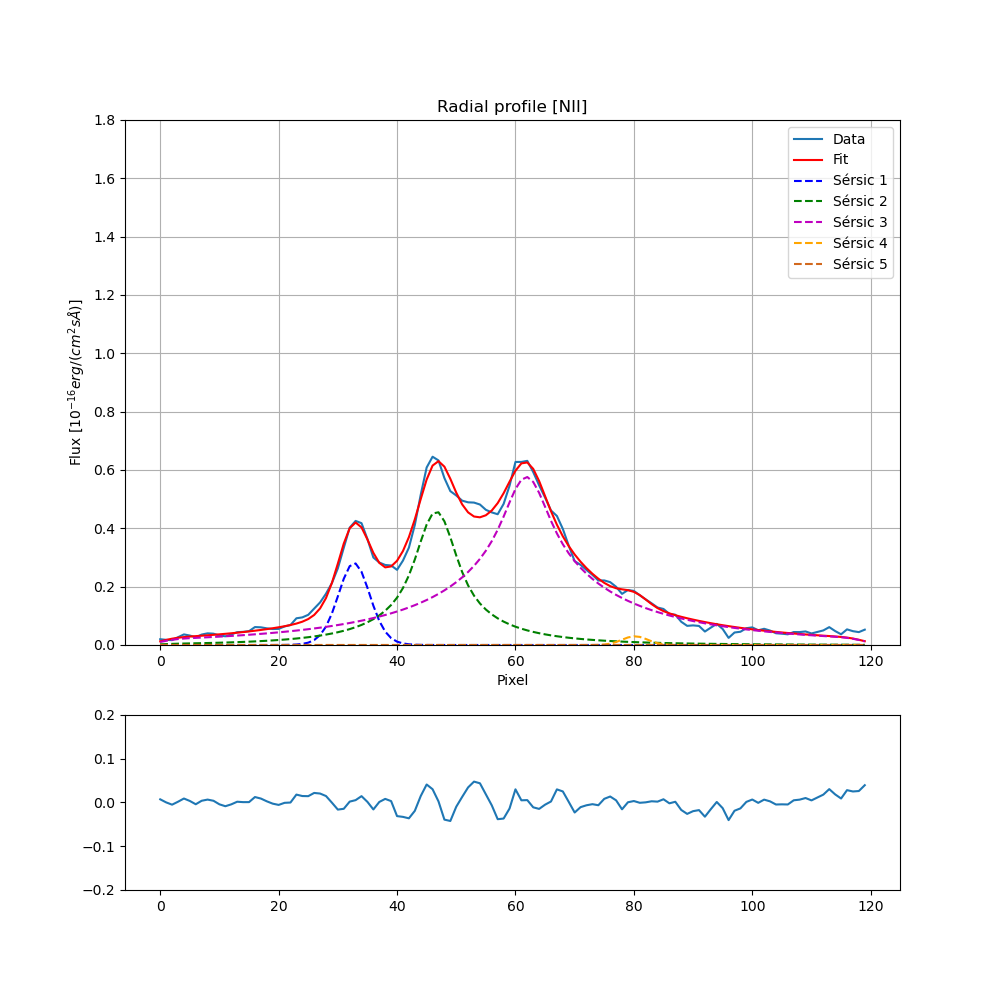

In [31]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [32]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.1147, r_e=2.3071, n=1.1481, x_0=32.7595
Sérsic 2: I_e=0.0137, r_e=43.1606, n=2.4688, x_0=46.6001
Sérsic 3: I_e=0.0498, r_e=34.4461, n=1.5456, x_0=61.8253
Sérsic 4: I_e=0.0438, r_e=0.1024, n=3.9780, x_0=80.1642
Sérsic 5: I_e=0.0496, r_e=0.0000, n=0.8523, x_0=100.5415
[inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf]
0.09420389081844163


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\738905611.py:3: OptimizeWarning: Covariance of the parameters could not be estimated
  params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII,


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


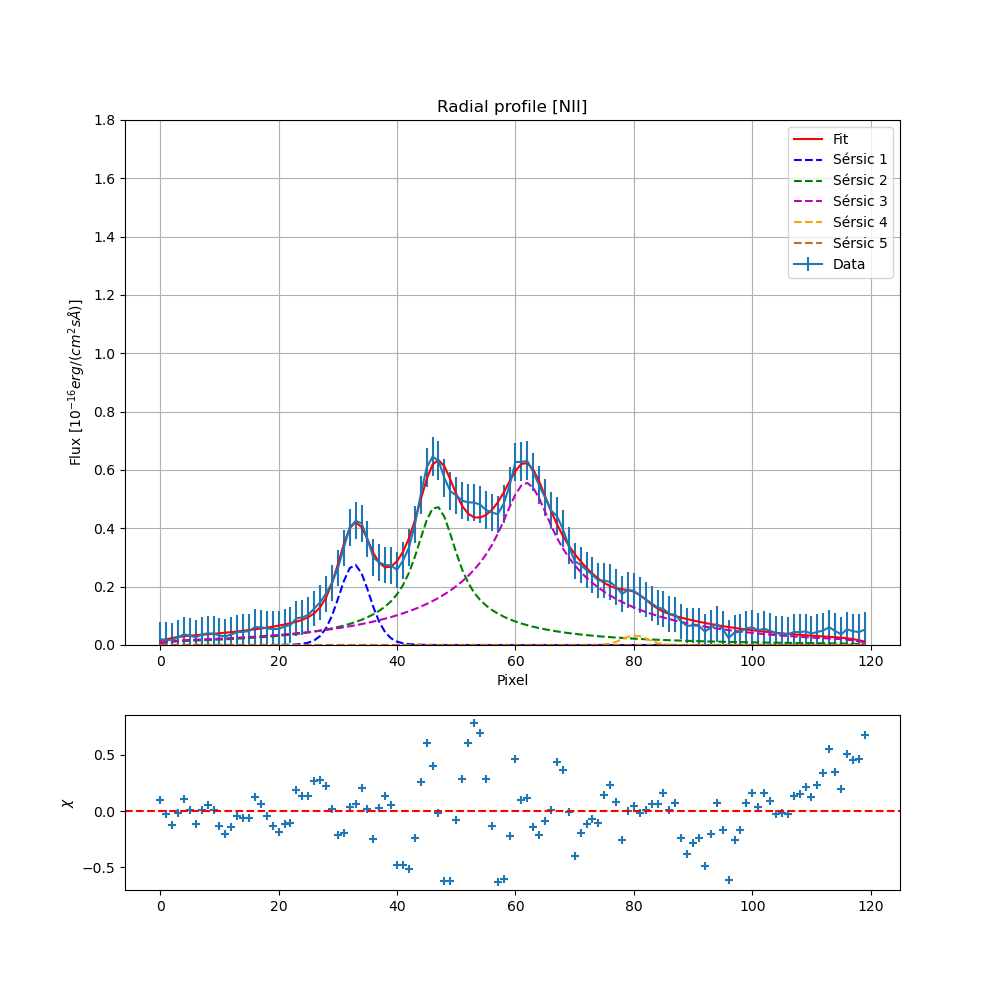

In [33]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

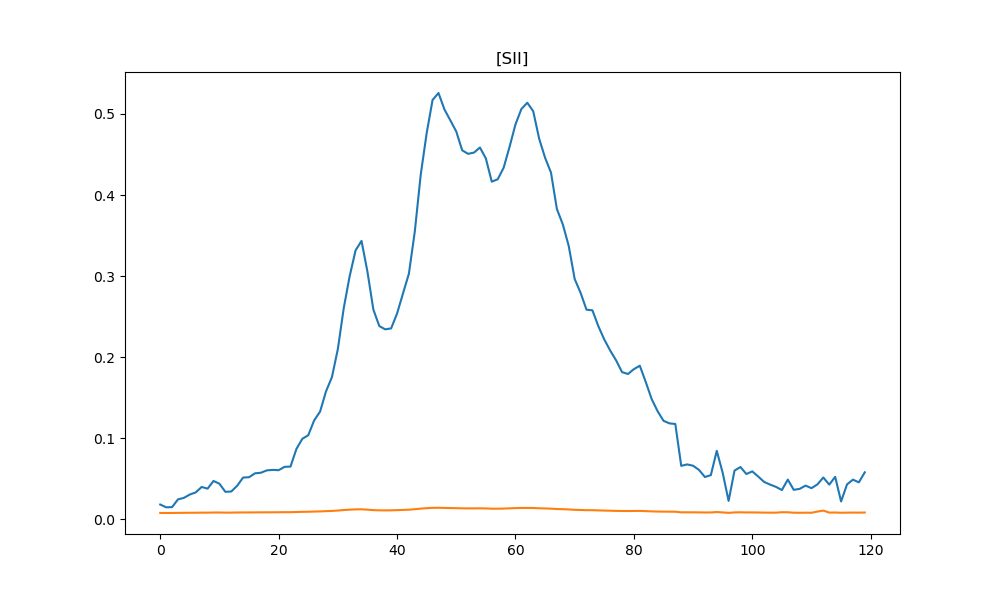

In [34]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [35]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7592.314541934094
differential_evolution step 2: f(x)= 3844.35539844376
differential_evolution step 3: f(x)= 3844.35539844376
differential_evolution step 4: f(x)= 3771.990582818414
differential_evolution step 5: f(x)= 3688.1933451393706
differential_evolution step 6: f(x)= 1297.9271673018552
differential_evolution step 7: f(x)= 1203.0244477401989
differential_evolution step 8: f(x)= 1203.0244477401989
differential_evolution step 9: f(x)= 1203.0244477401989
differential_evolution step 10: f(x)= 1203.0244477401989
differential_evolution step 11: f(x)= 1008.2905075296442
differential_evolution step 12: f(x)= 822.2899083174253
differential_evolution step 13: f(x)= 132.9429944640865
differential_evolution step 14: f(x)= 132.9429944640865
differential_evolution step 15: f(x)= 132.9429944640865
differential_evolution step 16: f(x)= 132.9429944640865
differential_evolution step 17: f(x)= 132.9429944640865
differential_evolution step 18: f(x)= 132.9429944640

Sérsic 1: I_e=0.8211, r_e=0.1530, n=1.3972, x_0=32.8313
Sérsic 2: I_e=0.0455, r_e=19.9742, n=1.3784, x_0=47.2846
Sérsic 3: I_e=0.0458, r_e=39.6820, n=1.4104, x_0=62.5471
Sérsic 4: I_e=2.4313, r_e=0.0229, n=0.2308, x_0=80.9636
Sérsic 5: I_e=0.0000, r_e=0.5190, n=0.5324, x_0=100.7883


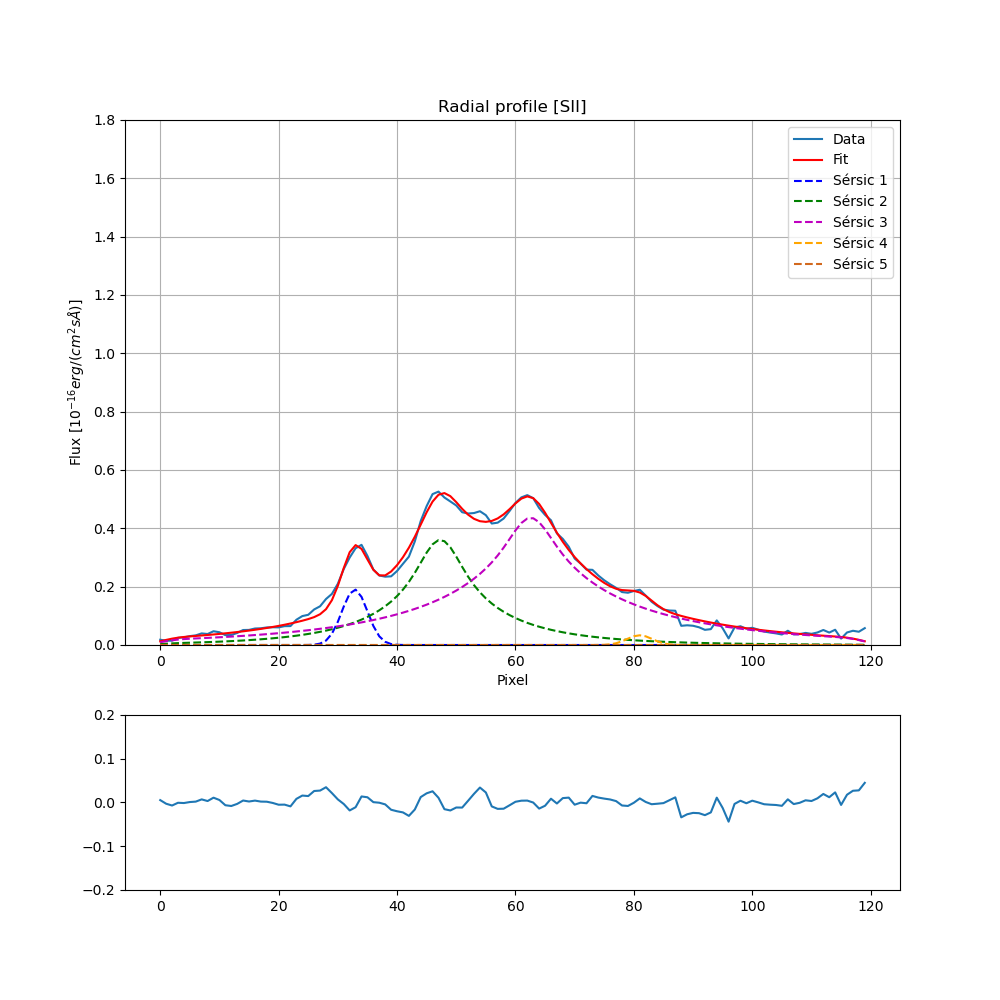

In [36]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [37]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0220, r_e=4.1407, n=2.3727, x_0=32.7927
Sérsic 2: I_e=0.0393, r_e=19.9816, n=1.4943, x_0=47.3276
Sérsic 3: I_e=0.0490, r_e=38.2114, n=1.3847, x_0=62.4201
Sérsic 4: I_e=2.4279, r_e=0.0233, n=0.2309, x_0=81.0498
Sérsic 5: I_e=0.0000, r_e=0.5190, n=0.5324, x_0=100.7883
[1.95945293e-01 2.00585232e+01 2.23736413e+01 3.98892969e-02
 1.84518053e-02 1.18906809e+01 3.17029551e-01 1.71071128e-01
 7.73472909e-03 4.36113825e+00 9.01591713e-02 2.23557520e-01
 1.36648340e+06 4.81691509e+03 5.68650511e+05 7.80862892e+03
 2.17961376e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00]
0.06316521679780467


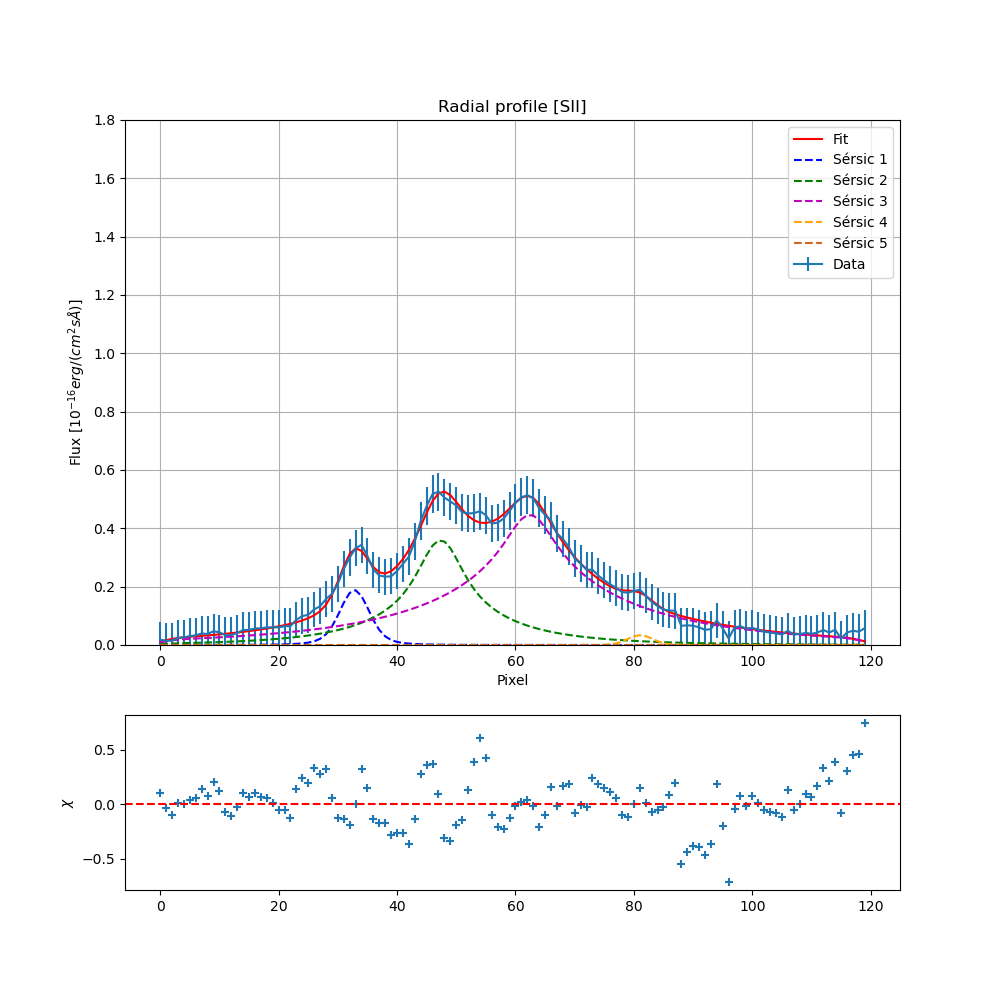

In [38]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

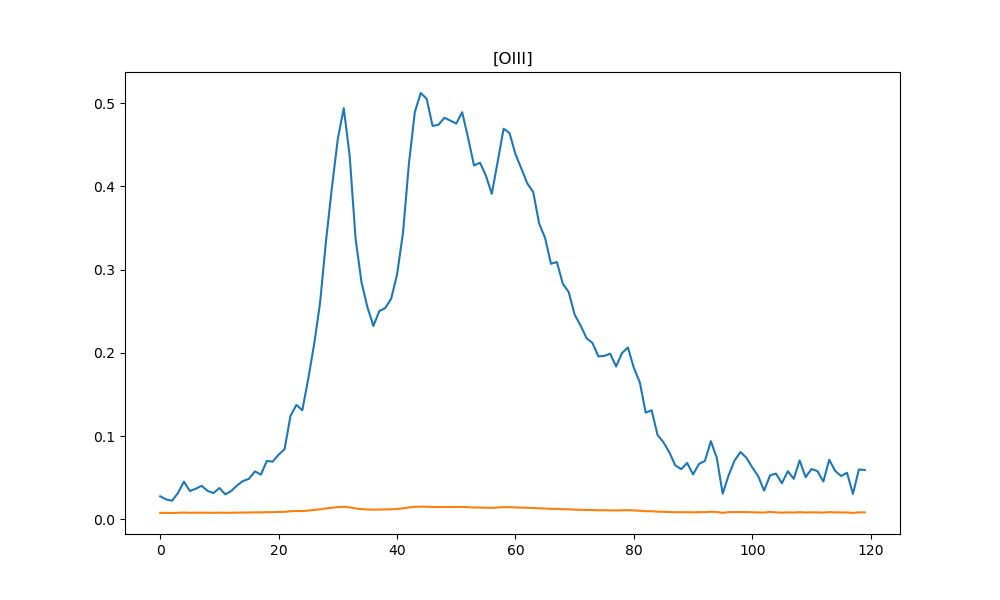

In [39]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [40]:
# Bounds:
bounds = bounds_OIII
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 21843.099027049855
differential_evolution step 2: f(x)= 8713.931126980371
differential_evolution step 3: f(x)= 8690.182910002364
differential_evolution step 4: f(x)= 3390.051563336157
differential_evolution step 5: f(x)= 3181.6559369271936
differential_evolution step 6: f(x)= 3181.6559369271936
differential_evolution step 7: f(x)= 2569.6404427233642
differential_evolution step 8: f(x)= 1114.0809335242097
differential_evolution step 9: f(x)= 1114.0809335242097
differential_evolution step 10: f(x)= 1114.0809335242097
differential_evolution step 11: f(x)= 681.2979114362405
differential_evolution step 12: f(x)= 681.2979114362405
differential_evolution step 13: f(x)= 681.2979114362405
differential_evolution step 14: f(x)= 681.2979114362405
differential_evolution step 15: f(x)= 231.3871680313506
differential_evolution step 16: f(x)= 126.66252663664542
differential_evolution step 17: f(x)= 126.66252663664542
differential_evolution step 18: f(x)= 126.662526

Sérsic 1: I_e=0.0320, r_e=1.1742, n=3.8934, x_0=30.1740
Sérsic 2: I_e=0.0261, r_e=49.1467, n=1.7492, x_0=45.8239
Sérsic 3: I_e=0.0687, r_e=19.9139, n=0.9788, x_0=60.2121
Sérsic 4: I_e=0.0048, r_e=8.4012, n=2.4447, x_0=78.9946
Sérsic 5: I_e=3.9843, r_e=0.0081, n=8.9836, x_0=99.5748


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_22932\2853382839.py:70: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


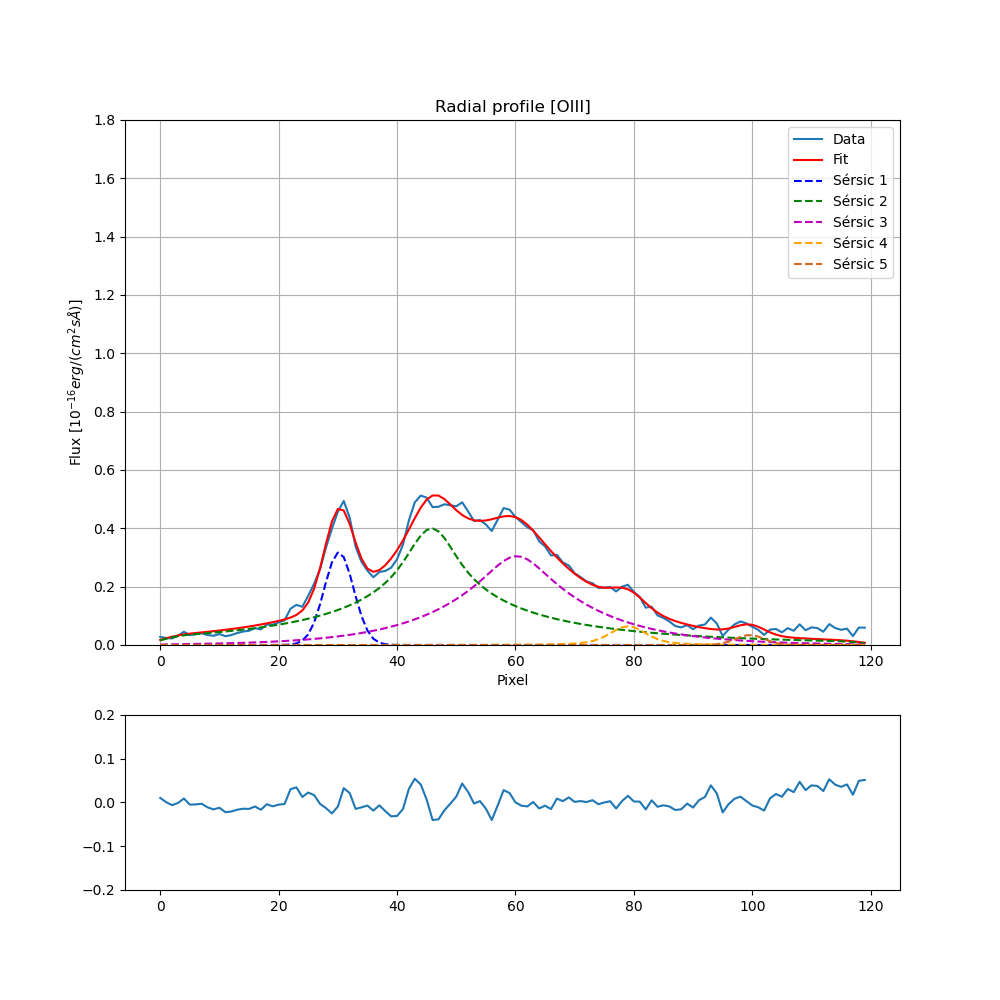

In [41]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [42]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0324, r_e=1.1766, n=3.8926, x_0=30.1740
Sérsic 2: I_e=0.0259, r_e=49.1687, n=1.7506, x_0=45.7902
Sérsic 3: I_e=0.0696, r_e=19.9199, n=0.9726, x_0=60.1735
Sérsic 4: I_e=0.0041, r_e=8.4038, n=2.6794, x_0=78.9167
Sérsic 5: I_e=3.9842, r_e=0.0069, n=8.9837, x_0=99.5737
[7.55953691e+00 1.42056980e+02 7.63508392e+02 1.30608797e-01
 2.21125132e-02 2.08776889e+01 4.42245407e-01 3.72506647e-01
 5.00001219e-02 3.33652923e+01 5.93890254e-01 6.60375940e-01
 3.92668668e-01 5.28756420e+02 1.24822695e+02 2.96329749e-01
 3.32669618e+06 2.75590378e+03 1.49997063e+06 2.01115587e+02]
0.1408578410102756


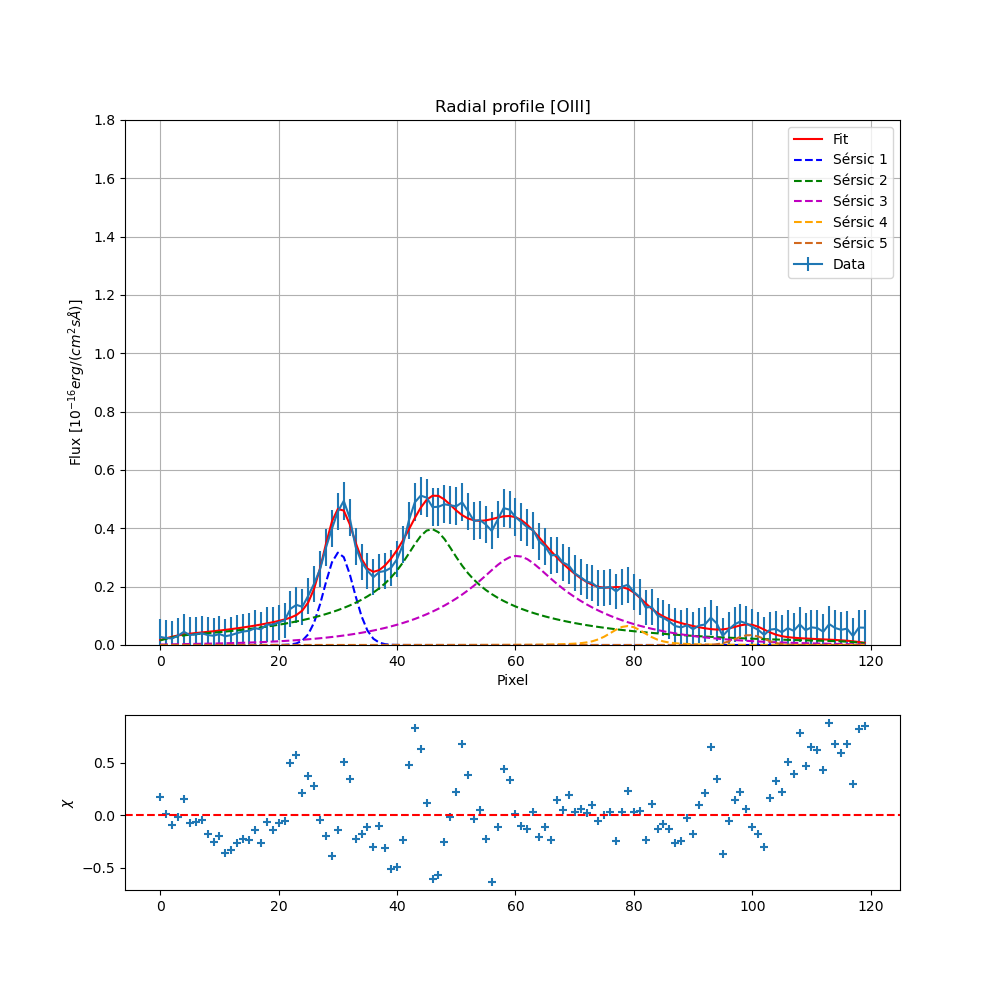

In [43]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [55]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

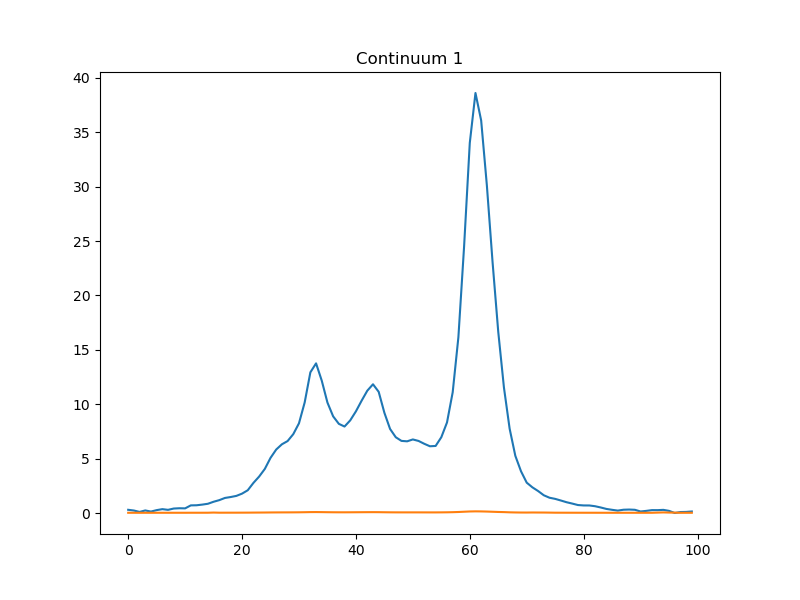

In [56]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [57]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3690.9908545962703
differential_evolution step 2: f(x)= 3050.220389991589
differential_evolution step 3: f(x)= 2855.430634180936
differential_evolution step 4: f(x)= 1972.8665633332828
differential_evolution step 5: f(x)= 1471.42110251332
differential_evolution step 6: f(x)= 1170.987345590995
differential_evolution step 7: f(x)= 1170.987345590995
differential_evolution step 8: f(x)= 1170.987345590995
differential_evolution step 9: f(x)= 1170.987345590995
differential_evolution step 10: f(x)= 1170.987345590995
differential_evolution step 11: f(x)= 1170.987345590995
differential_evolution step 12: f(x)= 1170.987345590995
differential_evolution step 13: f(x)= 886.3052806949128
differential_evolution step 14: f(x)= 708.4710247144553
differential_evolution step 15: f(x)= 708.4710247144553
differential_evolution step 16: f(x)= 708.4710247144553
differential_evolution step 17: f(x)= 708.4710247144553
differential_evolution step 18: f(x)= 708.4710247144553


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=2.2032, r_e=10.0000, n=1.0476, x_0=31.4673
Sérsic 2: I_e=2.5269, r_e=3.0000, n=0.2138, x_0=37.7089
Sérsic 3: I_e=4.3291, r_e=3.0000, n=0.4824, x_0=44.0108
Sérsic 4: I_e=0.8158, r_e=23.6623, n=2.4449, x_0=60.1590
Sérsic 5: I_e=13.5420, r_e=1.7624, n=0.3303, x_0=62.8248
Chi quadro minimo: 59.04200746881127
False


In [58]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=2.2032, r_e=10.0000, n=1.0476, x_0=31.4673
Sérsic 2: I_e=2.5269, r_e=3.0000, n=0.2138, x_0=37.7089
Sérsic 3: I_e=4.3291, r_e=3.0000, n=0.4824, x_0=44.0108
Sérsic 4: I_e=0.8158, r_e=23.6623, n=2.4449, x_0=60.1590
Sérsic 5: I_e=13.5420, r_e=1.7624, n=0.3303, x_0=62.8248


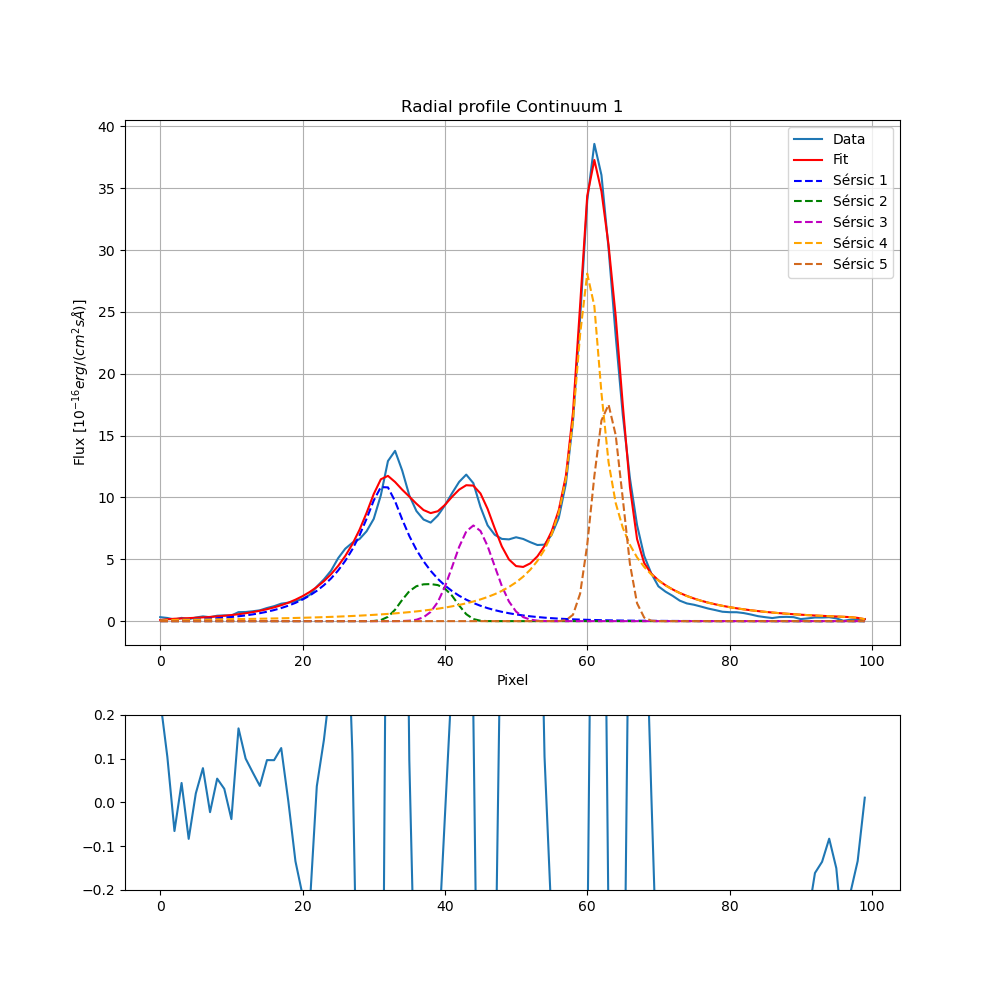

In [59]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [60]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.4799, r_e=10.0000, n=0.9401, x_0=31.4673
Sérsic 2: I_e=2.3206, r_e=3.0000, n=0.2084, x_0=37.7089
Sérsic 3: I_e=4.5607, r_e=3.0000, n=0.4498, x_0=44.0346
Sérsic 4: I_e=1.8863, r_e=12.8447, n=1.6745, x_0=59.8852
Sérsic 5: I_e=11.0830, r_e=2.1090, n=0.4926, x_0=62.8249
[0.89755946 0.52617855 0.11500632 2.0564234  2.34832526 2.56416688
 0.79372698 3.31359809 1.82471465 0.61408124 0.26340064 0.95916304
 0.36186728 1.24892979 0.26328209 0.16833684 4.6239057  0.58162602
 0.32583222 0.88651593]
7.77173833449348


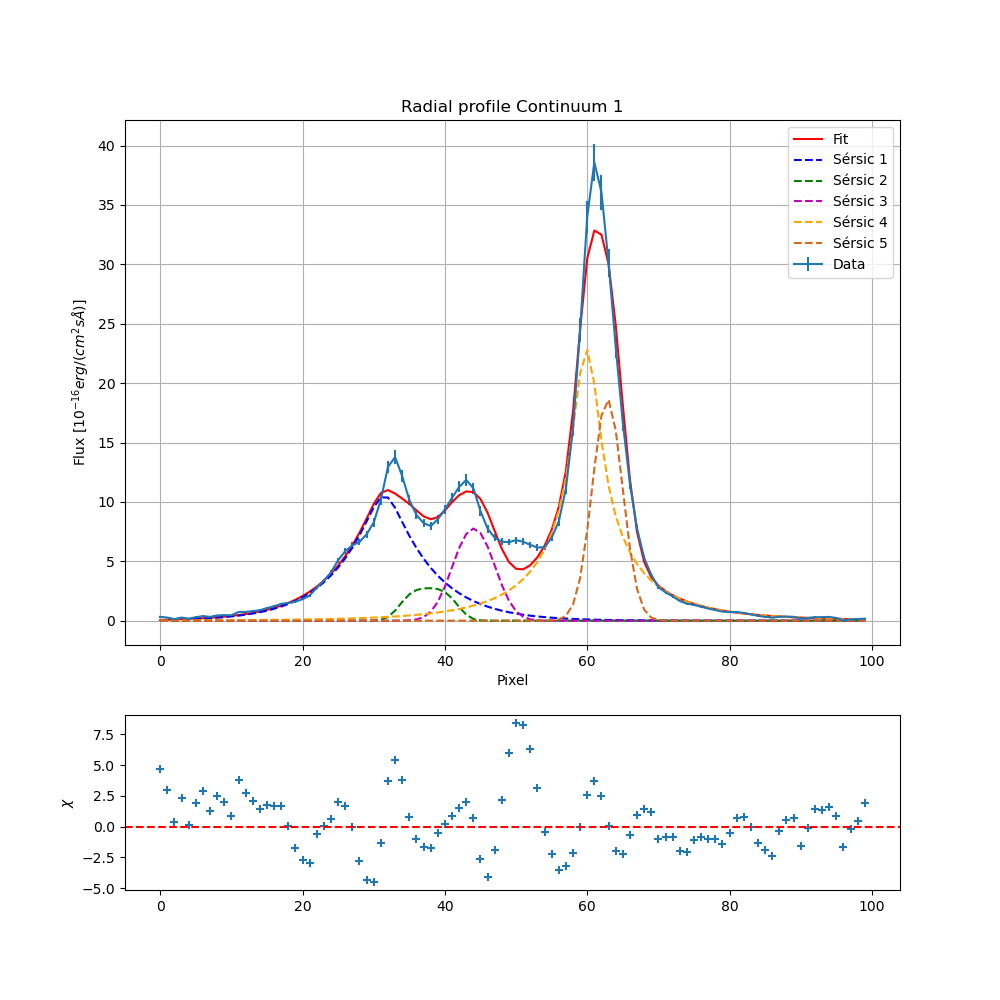

In [61]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

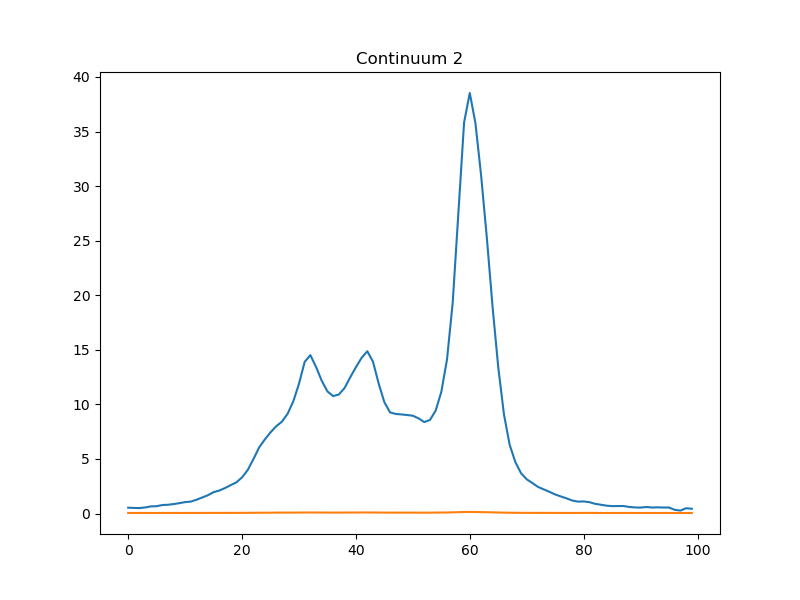

In [11]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [63]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3878.713461066773
differential_evolution step 2: f(x)= 3705.938422085638
differential_evolution step 3: f(x)= 3705.938422085638
differential_evolution step 4: f(x)= 1549.8000922985884
differential_evolution step 5: f(x)= 1549.8000922985884
differential_evolution step 6: f(x)= 1272.0293353667514
differential_evolution step 7: f(x)= 1272.0293353667514
differential_evolution step 8: f(x)= 1272.0293353667514
differential_evolution step 9: f(x)= 1272.0293353667514
differential_evolution step 10: f(x)= 989.7763810805044
differential_evolution step 11: f(x)= 989.7763810805044
differential_evolution step 12: f(x)= 989.7763810805044
differential_evolution step 13: f(x)= 989.7763810805044
differential_evolution step 14: f(x)= 776.2647662096684
differential_evolution step 15: f(x)= 734.5946024868681
differential_evolution step 16: f(x)= 679.6248979418873
differential_evolution step 17: f(x)= 523.5368133945343
differential_evolution step 18: f(x)= 523.536813394

Sérsic 1: I_e=4.0375, r_e=10.0000, n=0.7687, x_0=31.4673
Sérsic 2: I_e=3.5689, r_e=2.6639, n=0.1000, x_0=40.0899
Sérsic 3: I_e=4.7279, r_e=3.0000, n=0.2986, x_0=44.0346
Sérsic 4: I_e=2.2188, r_e=15.1004, n=1.9082, x_0=59.6435
Sérsic 5: I_e=9.3060, r_e=1.5007, n=0.1000, x_0=62.8248


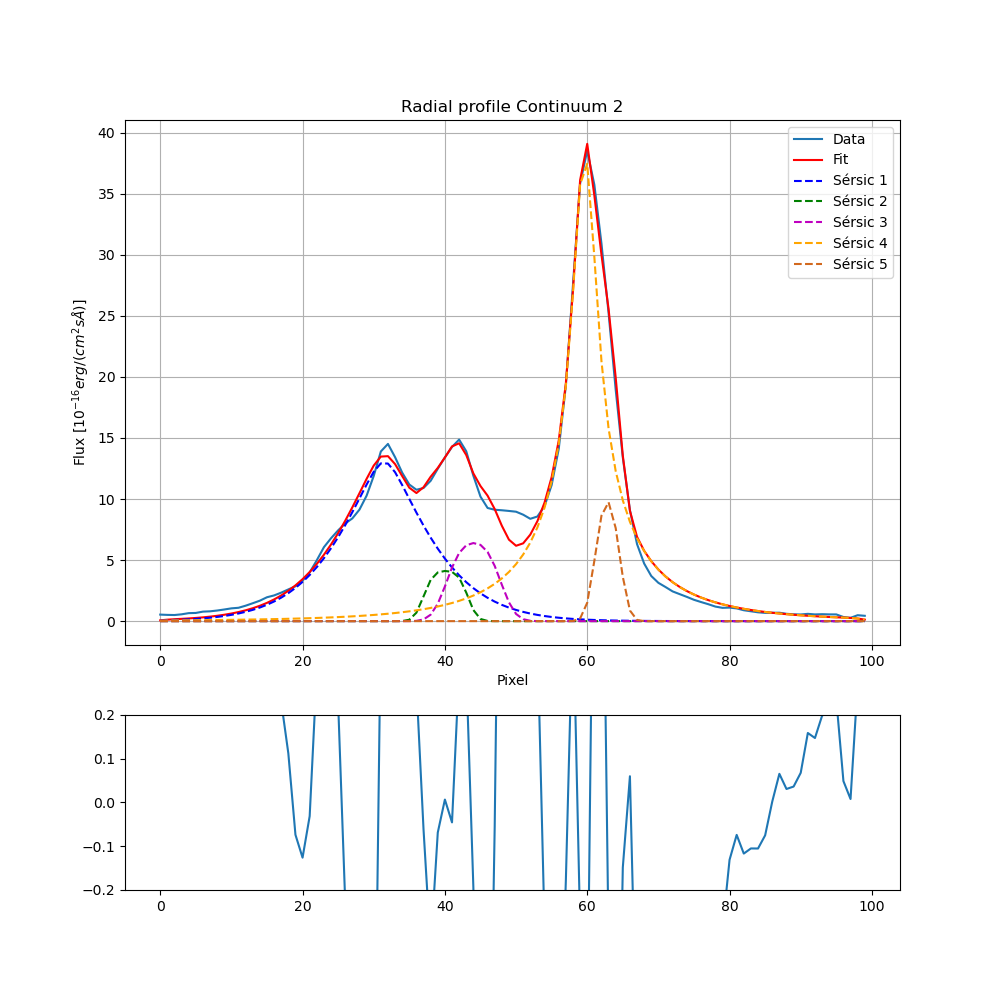

In [64]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [65]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=4.0141, r_e=10.0000, n=0.7795, x_0=31.4152
Sérsic 2: I_e=3.4601, r_e=2.5201, n=0.1006, x_0=40.0401
Sérsic 3: I_e=4.7950, r_e=3.0000, n=0.3189, x_0=44.0346
Sérsic 4: I_e=0.6814, r_e=29.3918, n=2.7332, x_0=58.8324
Sérsic 5: I_e=8.8422, r_e=1.8802, n=0.5394, x_0=62.8248
[ 0.43895977  0.44184221  0.07898792  0.52224974 33.83217109 21.60695566
  2.33638807  1.32578462  3.08926692  3.11704706  0.31743668  5.0089166
  0.22316591  5.93661862  0.29940376  0.24900751  3.92827046  0.48572799
  0.38272192  0.51223754]
10.144887652627109


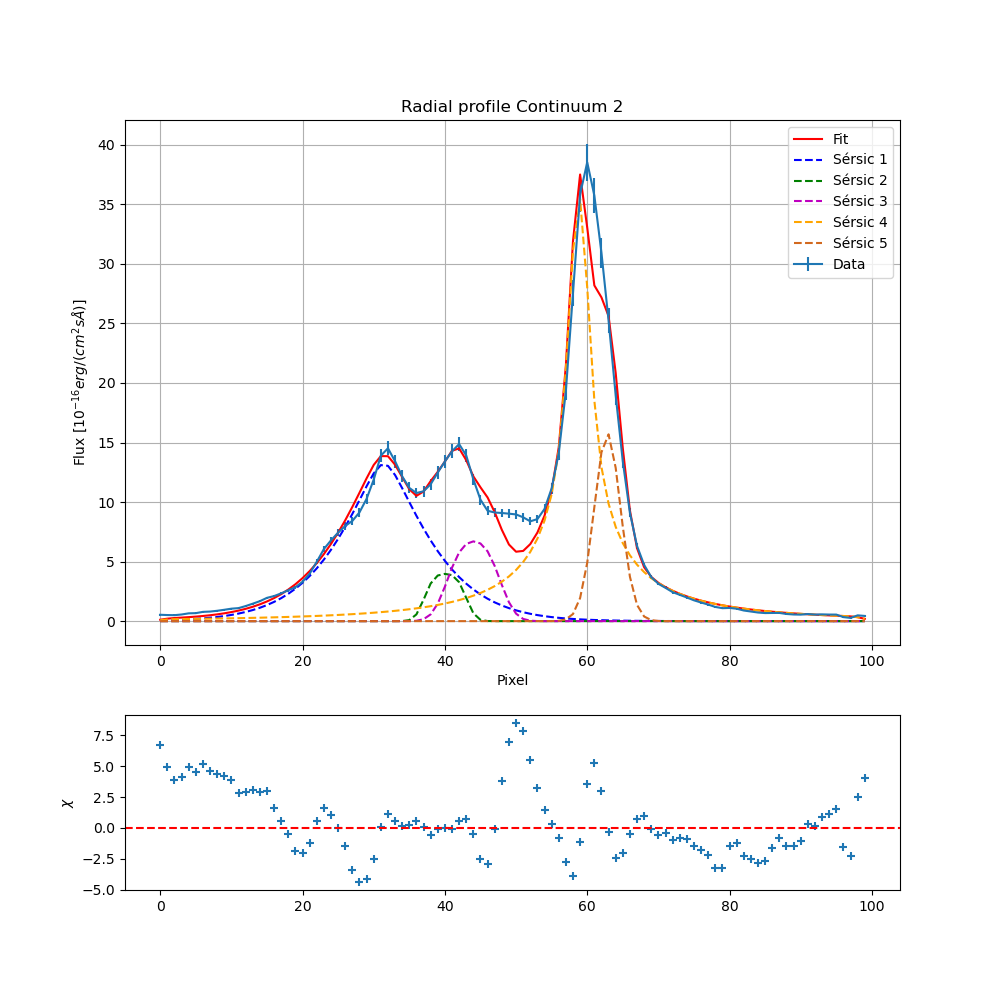

In [66]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

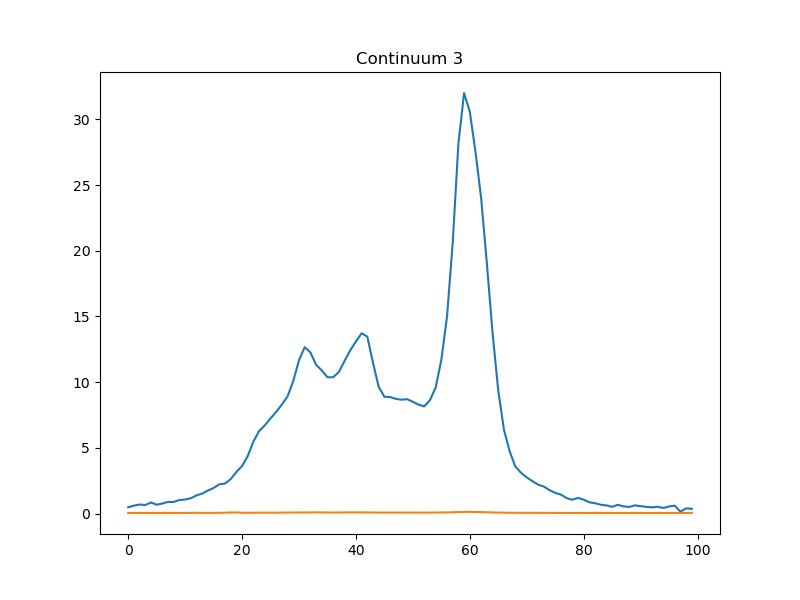

In [67]:
mask_continuum_3 =  (wv > 5950)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [68]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3504.2695624161074
differential_evolution step 2: f(x)= 3504.2695624161074
differential_evolution step 3: f(x)= 3365.2804376781446
differential_evolution step 4: f(x)= 2355.7801782849433
differential_evolution step 5: f(x)= 2355.7801782849433
differential_evolution step 6: f(x)= 2355.7801782849433
differential_evolution step 7: f(x)= 1425.1215678349233
differential_evolution step 8: f(x)= 1382.033351824987
differential_evolution step 9: f(x)= 1096.1349388455726
differential_evolution step 10: f(x)= 1096.1349388455726
differential_evolution step 11: f(x)= 1096.1349388455726
differential_evolution step 12: f(x)= 1096.1349388455726
differential_evolution step 13: f(x)= 1055.1622460075116
differential_evolution step 14: f(x)= 1055.1622460075116
differential_evolution step 15: f(x)= 983.6213420615425
differential_evolution step 16: f(x)= 983.6213420615425
differential_evolution step 17: f(x)= 983.6213420615425
differential_evolution step 18: f(x)= 983.62

Sérsic 1: I_e=4.3946, r_e=10.0000, n=0.6515, x_0=31.4673
Sérsic 2: I_e=3.6360, r_e=2.3424, n=0.1000, x_0=39.7787
Sérsic 3: I_e=4.1260, r_e=3.0000, n=0.2511, x_0=44.0346
Sérsic 4: I_e=2.7764, r_e=12.3794, n=1.6413, x_0=59.2010
Sérsic 5: I_e=6.7191, r_e=1.1951, n=0.1000, x_0=62.8248


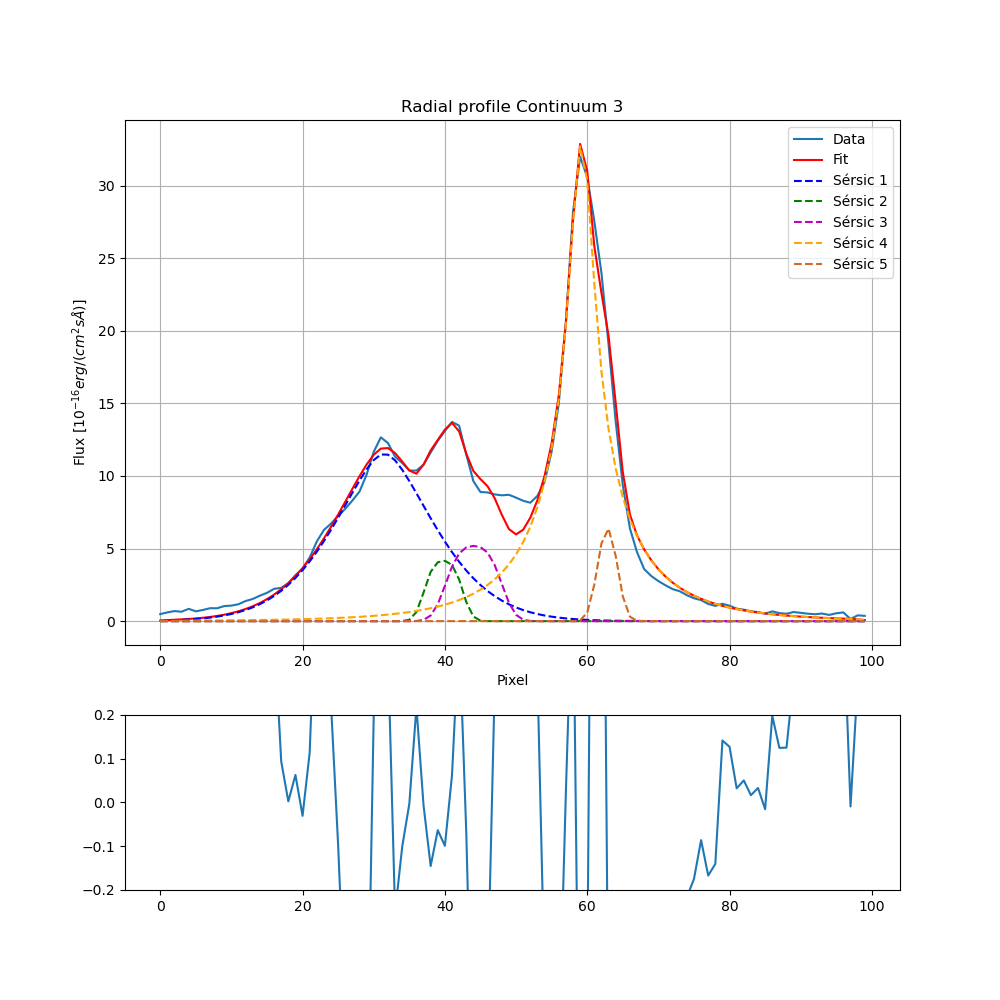

In [69]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [70]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=2.3513, r_e=13.6211, n=1.0092, x_0=30.8353
Sérsic 2: I_e=3.5259, r_e=1.7140, n=0.2462, x_0=40.8516
Sérsic 3: I_e=3.4005, r_e=6.6210, n=0.2864, x_0=43.9305
Sérsic 4: I_e=0.5593, r_e=29.7407, n=2.5732, x_0=58.4353
Sérsic 5: I_e=6.7236, r_e=2.5643, n=0.6901, x_0=61.4381
[0.2715763  0.52822763 0.06143262 0.61916923 2.59563944 0.36445244
 0.66482013 0.35823689 0.57591589 1.13543951 0.13693683 1.04480445
 0.17341185 5.37067069 0.34951992 0.21721259 1.95607172 0.32595497
 0.20391428 0.48508902]
2.8570801045055787


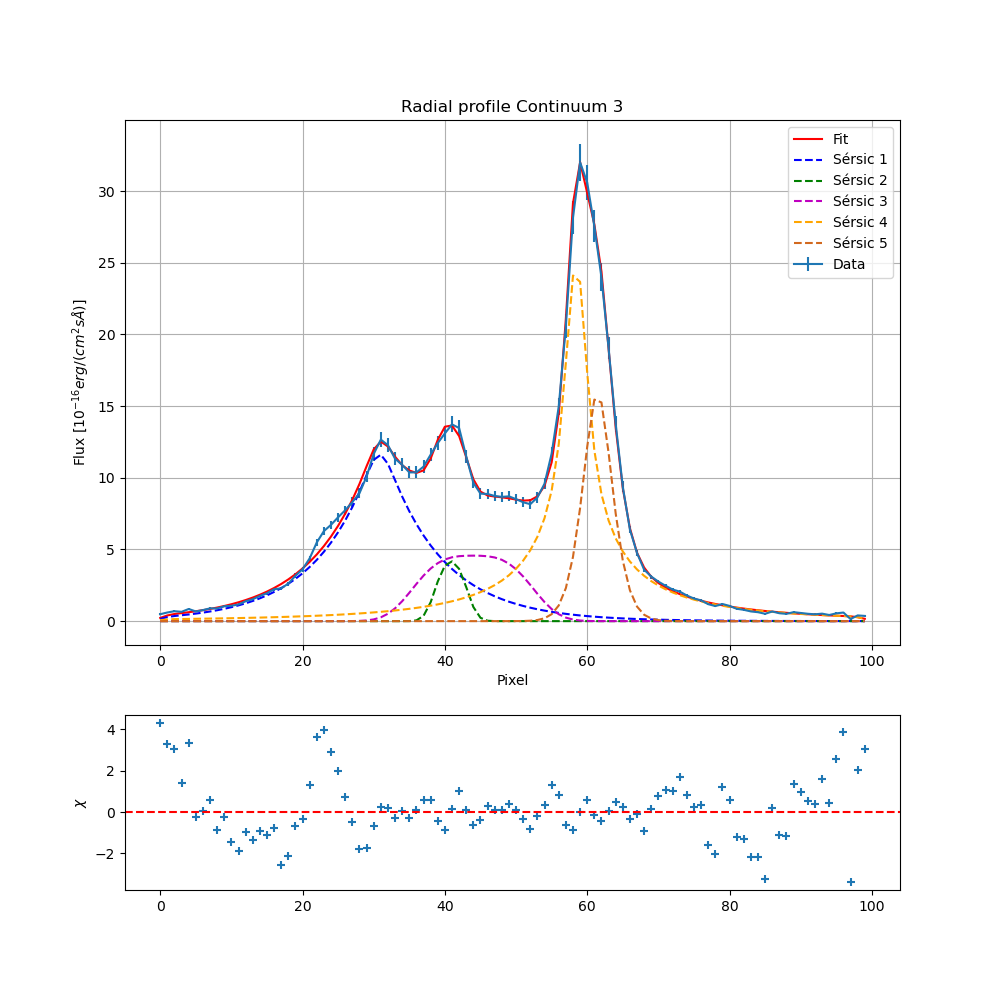

In [71]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [72]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

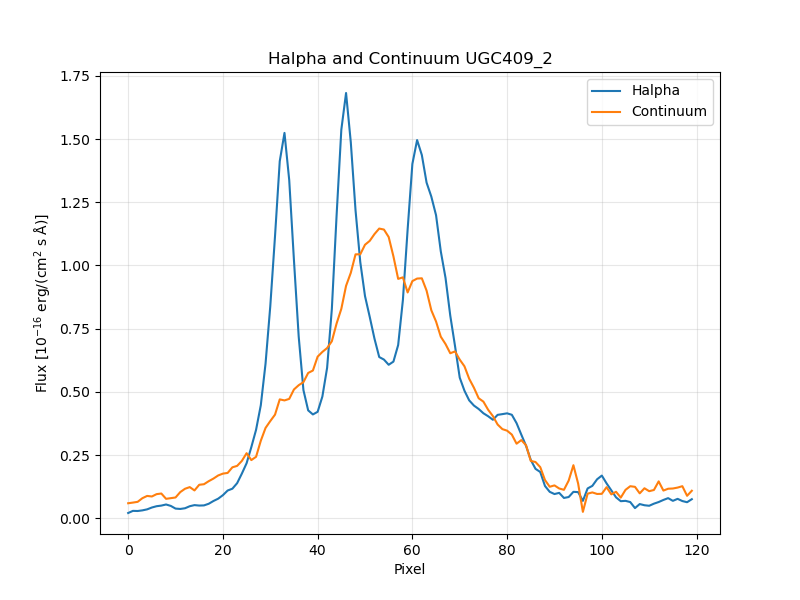

In [44]:
mask_continuum_3 = (wv > 6550)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum UGC409_2')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_UGC409_2')